# Computer Book A: Calculating quantiles

These series of codes, illustrate using python, the various exercises from the OU course M248 Analysing Data. The exercises were originally written to be carried out using Minitab statistical software but those exercises have been re-done in Python below

## Computer activity 45: Quantiles of an exponential distribution

In Computer activity 41, an exponential distribution with mean 330 was used to model the waiting time in days between successive serious earthquakes worldwide. In this activity you will find the median, quartiles and deciles of this distribution. 

**The median value of the exponential distribution with mean of 330:**

In [11]:
import math

lambda_rate = 67 / 22120
median = round(math.log(2) / lambda_rate,4)

print(f"The median waiting time between serious earthquakes is approximately {median} days")

The median waiting time between serious earthquakes is approximately 228.842 days


Note that quantiles of continuous variables are solved by finding the value of $x$ in the equation $f(x) = \alpha$. For example, in the above we use the exponetial distribution equation $f(x) = 1 - e^{-\lambda x}$ and set it to the median value of 0.5: $0.5 = 1 - e^{-\lambda x}$.

Re-arrange and taking the natural log on both sides yeilds:

* $e^{-\lambda x} = 0.5$

* $-\lambda x = \ln(0.5)$

* $x = \dfrac{\ln(0.5)}{-\lambda}$



**The upper, lower and inter quartile range of the exponential distribution with mean of 330:**

Using the same princples as above with the exponential distribution function to calculate the upper, lower and inter quartile

In [14]:
import math

lambda_rate = 67 / 22120

# Lower Quartile (25th percentile)
q1 = round(-math.log(0.75) / lambda_rate,4)

# Upper Quartile (75th percentile)
q3 = round(-math.log(0.25) / lambda_rate,4)

# Interquartile Range
iqr = q3 - q1

print(f"The upper quartile of waiting time between serious earhquakes is {q1}")
print(f"The upper quartile of waiting time between serious earhquakes is {q3}")
print(f"The inter-quartile range of waiting time between serious earhquakes is {iqr}")

The upper quartile of waiting time between serious earhquakes is 94.978
The upper quartile of waiting time between serious earhquakes is 457.684
The inter-quartile range of waiting time between serious earhquakes is 362.706


**The deciles of the exponential distribution with mean of 330:**

Using the same princples as above with the exponential distribution function to calculate the deciles and using looping functionality of python to get all the deciles from 0.1 to 0.9.

In [24]:
import math
import pandas as pd

lambda_rate = 67 / 22120

deciles = {}
for n in range(1, 10):
    p = n / 10
    val = round(-math.log(1 - p) / lambda_rate,4)
    deciles[f"nth_decile: {n/10}"] = val

print(deciles)
earthquake_waiting_times_d_series = pd.Series(deciles)
print("")
print(earthquake_waiting_times_d_series)

{'nth_decile: 0.1': 34.7847, 'nth_decile: 0.2': 73.6707, 'nth_decile: 0.3': 117.756, 'nth_decile: 0.4': 168.6487, 'nth_decile: 0.5': 228.842, 'nth_decile: 0.6': 302.5127, 'nth_decile: 0.7': 397.4907, 'nth_decile: 0.8': 531.3547, 'nth_decile: 0.9': 760.1968}

nth_decile: 0.1     34.7847
nth_decile: 0.2     73.6707
nth_decile: 0.3    117.7560
nth_decile: 0.4    168.6487
nth_decile: 0.5    228.8420
nth_decile: 0.6    302.5127
nth_decile: 0.7    397.4907
nth_decile: 0.8    531.3547
nth_decile: 0.9    760.1968
dtype: float64


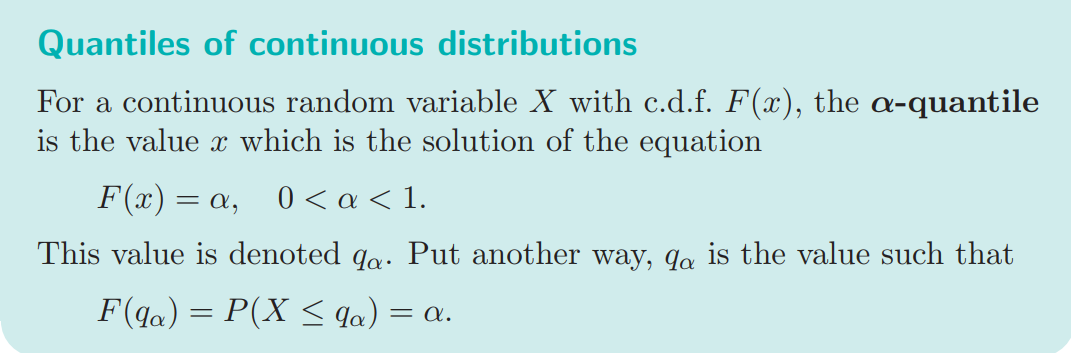

**Placing the deciles in a nice look table by using the Pandas library (DataFrame):**

In [4]:
import pandas as pd
import math

lambda_val = 67 / 22120

# Initializing lists for the dictionary
n_list = []
days_list = []

# Calculating D1 through D9
for n in range(1, 10):
    p = n / 10
    val = -math.log(1 - p) / lambda_val
    n_list.append(n)
    days_list.append(val)

# Creating the dictionary of lists
decile_dict = {
    "deciles": n_list,
    "days": days_list
}

df = pd.DataFrame(decile_dict)
df

,deciles,days
0,1,34.784696
1,2,73.670677
2,3,117.755967
3,4,168.648698
4,5,228.842024
5,6,302.512701
6,7,397.490723
7,8,531.354726
8,9,760.196750


#### Commentary (deciles)

The waiting times between earthquakes has been shown to fit an exponential model so that for example according to the model for q1 and q8 approximately 10% of intervals between serious earthquakes are shorter than 35 days and approximately 80% of intervals between serious earthquakes are more than 531 days

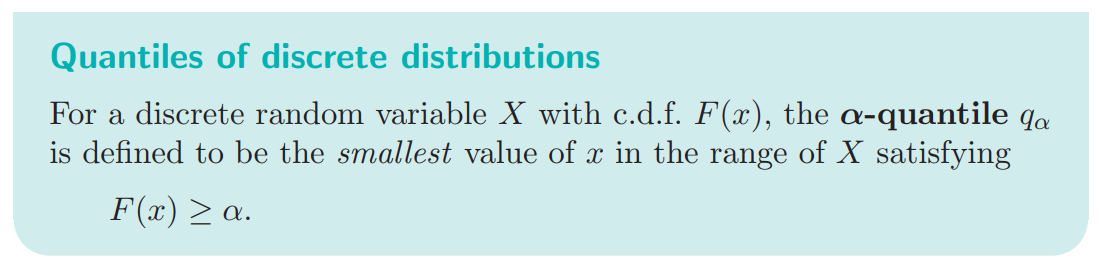

## Computer activity 46: Quantiles of a binomial distribution

In Computer activities 27 to 29, you found various probabilities associated with a multiple choice examination consisting of twenty questions. Each question had five options, exactly one of which was correct. If X is a random variable representing the number of questions answered correctly by a student who guesses answers at random, then X has a binomial distribution: $X ∼ B(20, 0.2)$. 

In this activity, you will find several quantiles for this distribution.

**Find the median score of students who guess answers at random**

In order to work out the median score of the binomial distribution: $X ∼ B(20, 0.2)$ we need to consider the value of the random variable which has a CDF less than 0.5 and the value of the random variable which has a CDF greater than 0.5. 

The median $m$ is defined to be the smallest value of $x$ in the range of $X$ for which $F(x) ≥ 0.5$.

Hence:<br>

$P(X \le 3) \approx 0.411$ and $P(X \le 4) \approx 0.630$

And thus the median score is 4 (since 4 is the first number where the cumulative probability reaches or passes 
0.5 i.e. 0.630)

In [13]:
from scipy.stats import binom

n = 20
p = 0.2

# Calculate cumulative probabilities P(X <= x)
prob_3 = round(float(binom.cdf(3, n, p)), 4)
prob_4 = round(float(binom.cdf(4, n, p)), 4)

print(f"{prob_3=}")
print(f"{prob_4=}")

prob_3=0.4114
prob_4=0.6296


**Find the lower quartile and the upper quartile of the random variable X**.

Using similar arguments in find the median value of the random variable we describe that:
1. The lower quarter will be the smallest value of $x$ in the range of $X$ for which $F(x) ≥ 0.25$
2. The upper quarter will be the smallest value of $x$ in the range of $X$ for which $F(x) ≥ 0.75$

Hence (for the lower quartile):<br>

$P(X \le 2) \approx 0.206$ and $P(X \le 3) \approx 0.411$

And thus the lower quarter score is 3 (since 3 is the first number where the cumulative probability reaches or passes 
0.25 i.e. 0.411)

Hence (for the upper quartile):<br>

$P(X \le 4) \approx 0.630$ and $P(X \le 5) \approx 0.804$

And thus the upper quarter score is 5 (since 5 is the first number where the cumulative probability reaches or passes 
0.75 i.e. 0.804)

In [19]:
from scipy.stats import binom

n = 20
p = 0.2

# Check cumulative probabilities for Q1 and Q3
results = {k: round(float(binom.cdf(k, n, p)),4) for k in range(2, 7)}
print(results)

{2: 0.2061, 3: 0.4114, 4: 0.6296, 5: 0.8042, 6: 0.9133}


**The pass mark is to be set so that only one in a thousand students who guess answers at random will pass. What quantile of X should you find in order to determine what the pass mark should be? What should the pass mark be?**

The pass mark will be such that those students who pass must be in the top 0.1% and the rest that fail will be in the 99.9% of the probability distribution which is in a 0.9999-tile range (the one in a thousand is basically the probability that a student will pass; this will be at the extreme end of the distribution hence: 1-0.1 = 99.9). So according to the CDF the probability of passing greater than 0.999-tile (given that below the 0.999-tile represents failure) and the random variable corresponding to it will be the required pass mark

Hence (for the 0.999-tile):<br>

$P(X \le 9) \approx 0.997$ and $P(X \le 10) \approx 0.999$


In [1]:
from scipy.stats import binom

n = 20
p = 0.2

# Calculate cumulative probabilities P(X <= x)
prob_9 = round(float(binom.cdf(9, n, p)), 3)
prob_10 = round(float(binom.cdf(10, n, p)), 3)

print(f"{prob_9=}")
print(f"{prob_10=}")

prob_9=0.997
prob_10=0.999


#### Commentary

Given that this (the required pass mark) is a discrete random variable hence: $P(X < x) = P(X \le x - 1)$ but $P(X<x)$ and $P(X\leq x)$ are not the same.

A passmark of 10 (11 - 1) is on the 0.999-tile (the highest score that fails the exam) but because this is a discrete random variable this means that the 11 becomes the pass mark to make it above the 0.999-tile i.e. the 1 in a thousand student that passes

## Computer activity 47: Quantiles of Poisson distributions

In Computer activity 41, a Poisson distribution with parameter 4.425 was used to model the number of serious earthquakes that occur in a typical four year period. 

**According to this model, what is the median number of serious earthquakes that occur in a four-year period?**

In [11]:
import math
import pandas as pd

lambda_rate_time = 4.425

def poisson_pmf(k, lam):
    return (math.exp(-lam) * (lam**k)) / math.factorial(k)

probabilities = []
cumulative_prob = 0
results = []
pmf_values = []
cumulative_values = []

for k in range(6):
    pmf = poisson_pmf(k, lambda_rate_time)
    cumulative_prob += pmf
    results.append((k, pmf, cumulative_prob))
    
    pmf_values.append(pmf)
    cumulative_values.append(cumulative_prob)

# Creating the dictionary of lists
results = {
    "pmf": pmf_values,
    "cumulative_pmf": cumulative_values
}

df = pd.DataFrame(results)
df

,pmf,cumulative_pmf
0,0.011974,0.011974
1,0.052986,0.064960
2,0.117231,0.182191
3,0.172916,0.355107
4,0.191288,0.546396
5,0.169290,0.715686


### Commentary

In order to find the median number of earthquakes we need to find the value of the random variable where:
$P(X \le x) \ge 0.5$ i.e. the smallest value of the random variable which has a probability at least equal to or greater than the median i.e. 0.5.

Since Poisson distribution has no CDF function cumumlative pmf is calculated and the smallest value of $x$ which is equal to or greater than 0.5 is the median number of earthquakes in a 4 year period. 

In this case it is 4.

Telephone calls arrive at a switchboard at random at an average rate of 40 per hour. The number of calls that arrive in an hour may be modelled by a Poisson distribution with parameter 40.

**What is the largest number of calls received during any of the 10% of hours that are the quietest?**

The number of calls, $X$, with $\lambda = 40$ (mean) and $t = 1$, follows a Poisson distribution: $X \sim \text{Poisson}(40)$. 

We need to find the largest number of calls such that $X < k$ where the probability is less than or equal to 0.10 i.e. $P(X \leq k) \leq 0.10$.

Of course since the Poisson distribution does not have a CDF we would need to sum up all the probabilities for each $x$ such that we pick the one which has a value of $X < k$ (we exclude $x$ less than 30 because $\lambda$ is so large i.e. 40 that the probability values at $x$ =1,2,3 etc are too miniscule and unnecessary to compute.

In [7]:
import math
import pandas as pd

def poisson_prob(lambda_rate_time, x):
    return (math.exp(-lmbda) * (lambda_rate_time**x)) / math.factorial(x)

lambda_rate_time = 40
cumulative_prob = 0
results = []

for x in range(35):
    prob = poisson_prob(lambda_rate_time, x)
    cumulative_prob += prob
    if x >= 30:
        results.append((x, cumulative_prob))

# Creating the dictionary of lists - fixed to use the results list
results_dict = {
    "X": [result[0] for result in results],  # Extract x values from tuples
    "cumulative_pmf": [result[1] for result in results]  # Extract cumulative_prob values from tuples
}

df = pd.DataFrame(results_dict)  # Use the dictionary with lists

print(df)  # Uncommented to show the results

# print(results)

    X  cumulative_pmf
0  30        0.061694
1  31        0.085521
2  32        0.115304
3  33        0.151404
4  34        0.193876


### Commentary

Giving the output of the different probabilities for the random variable $X$ above it would seem that 32 calls would fall within less than or equal to 10% given that $X$ is discrete i.e. $X$ cannot be placed at 31 calls.

**What is the largest number of calls received during any of the 1% of hours that are the quietest?**

sssdf

In [11]:
import math
import pandas as pd

def poisson_prob(lambda_rate_time, x):
    return (math.exp(-lmbda) * (lambda_rate_time**x)) / math.factorial(x)

lambda_rate_time = 40
cumulative_prob = 0
results = []

for x in range(30):
    prob = poisson_prob(lambda_rate_time, x)
    cumulative_prob += prob
    if x >= 25:
        results.append((x, cumulative_prob))

# Creating the dictionary of lists - fixed to use the results list
results_dict = {
    "X": [result[0] for result in results],  # Extract x values from tuples
    "cumulative_pmf": [result[1] for result in results]  # Extract cumulative_prob values from tuples
}

df = pd.DataFrame(results_dict)  # Use the dictionary with lists

print(df)  # Uncommented to show the results

# print(results)

    X  cumulative_pmf
0  25        0.007566
1  26        0.012311
2  27        0.019339
3  28        0.029380
4  29        0.043229


### Commentary

Giving the output of the different probabilities for the random variable $X$ above it would seem that 26 calls would fall within less than or equal to 1% given that $X$ is discrete i.e. $X$ cannot be placed at 25 calls.